In [263]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv('amazon_products_sales_data_uncleaned.csv')
df.head()

,title,rating,number_of_reviews,bought_in_last_month,current/discounted_price,price_on_variant,listed_price,is_best_seller,is_sponsored,is_couponed,buy_box_availability,delivery_details,sustainability_badges,image_url,product_url,collected_at
0,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,4.6 out of 5 stars,375,300+ bought in past month,89.68,basic variant price: 2.4GHz,$159.00,No Badge,Sponsored,Save 15% with coupon,Add to cart,"Delivery Mon, Sep 1",Carbon impact,https://m.media-amazon.com/images/I/71pAqiVEs3...,/sspa/click?ie=UTF8&spc=MTo4NzEzNDY2NTQ5NDYxND...,2025-08-21 11:14:29
1,"LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...",4.3 out of 5 stars,"2,457",6K+ bought in past month,9.99,basic variant price: nan,$15.99,No Badge,Sponsored,No Coupon,Add to cart,"Delivery Fri, Aug 29",NaN,https://m.media-amazon.com/images/I/61nbF6aVIP...,/sspa/click?ie=UTF8&spc=MTo4NzEzNDY2NTQ5NDYxND...,2025-08-21 11:14:29
2,"DJI Mic 2 (2 TX + 1 RX + Charging Case), Wirel...",4.6 out of 5 stars,"3,044",2K+ bought in past month,314.00,basic variant price: nan,$349.00,No Badge,Sponsored,No Coupon,Add to cart,"Delivery Mon, Sep 1",NaN,https://m.media-amazon.com/images/I/61h78MEXoj...,/sspa/click?ie=UTF8&spc=MTo4NzEzNDY2NTQ5NDYxND...,2025-08-21 11:14:29
3,"Apple AirPods Pro 2 Wireless Earbuds, Active N...",4.6 out of 5 stars,"35,882",10K+ bought in past month,NaN,basic variant price: $162.24,No Discount,Best Seller,Organic,No Coupon,NaN,NaN,NaN,https://m.media-amazon.com/images/I/61SUj2aKoE...,/Apple-Cancellation-Transparency-Personalized-...,2025-08-21 11:14:29
4,Apple AirTag 4 Pack. Keep Track of and find Yo...,4.8 out of 5 stars,"28,988",10K+ bought in past month,NaN,basic variant price: $72.74,No Discount,No Badge,Organic,No Coupon,NaN,NaN,NaN,https://m.media-amazon.com/images/I/61bMNCeAUA...,/Apple-MX542LL-A-AirTag-Pack/dp/B0D54JZTHY/ref...,2025-08-21 11:14:29


In [264]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42675 entries, 0 to 42674
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   title                     42675 non-null  object
 1   rating                    41651 non-null  object
 2   number_of_reviews         41651 non-null  object
 3   bought_in_last_month      39458 non-null  object
 4   current/discounted_price  30926 non-null  object
 5   price_on_variant          42675 non-null  object
 6   listed_price              42675 non-null  object
 7   is_best_seller            42675 non-null  object
 8   is_sponsored              42675 non-null  object
 9   is_couponed               42675 non-null  object
 10  buy_box_availability      28022 non-null  object
 11  delivery_details          30955 non-null  object
 12  sustainability_badges     3408 non-null   object
 13  image_url                 42675 non-null  object
 14  product_url           

title                           0
rating                       1024
number_of_reviews            1024
bought_in_last_month         3217
current/discounted_price    11749
price_on_variant                0
listed_price                    0
is_best_seller                  0
is_sponsored                    0
is_couponed                     0
buy_box_availability        14653
delivery_details            11720
sustainability_badges       39267
image_url                       0
product_url                  2069
collected_at                    0
dtype: int64

--------------------------------------------clean data--------------------------------------------


In [265]:
df.columns

Index(['title', 'rating', 'number_of_reviews', 'bought_in_last_month',
       'current/discounted_price', 'price_on_variant', 'listed_price',
       'is_best_seller', 'is_sponsored', 'is_couponed', 'buy_box_availability',
       'delivery_details', 'sustainability_badges', 'image_url', 'product_url',
       'collected_at'],
      dtype='object')

In [266]:
df.dtypes

title                       object
rating                      object
number_of_reviews           object
bought_in_last_month        object
current/discounted_price    object
price_on_variant            object
listed_price                object
is_best_seller              object
is_sponsored                object
is_couponed                 object
buy_box_availability        object
delivery_details            object
sustainability_badges       object
image_url                   object
product_url                 object
collected_at                object
dtype: object

In [267]:
df['rating']=df['rating'].str.extract(r"(\d+\.\d+)")
df['rating']

0        4.6
1        4.3
2        4.6
3        4.6
4        4.8
        ... 
42670    5.0
42671    4.2
42672    4.3
42673    4.7
42674    4.4
Name: rating, Length: 42675, dtype: object

In [268]:
df['rating']=df['rating'].astype(str).astype(float)

 * number of review


In [269]:
df['number_of_reviews'].isnull().sum()

np.int64(1024)

In [270]:
df['number_of_reviews'] = pd.to_numeric(
    df['number_of_reviews'].astype(str).str.replace(",", ""),
    errors='coerce'
)


In [271]:
df['number_of_reviews']=df['number_of_reviews'].fillna(df['number_of_reviews'].mean())

In [272]:
df['number_of_reviews'] = df['number_of_reviews'].astype(str).astype(float).astype(int)

 * bought_in_last_month

In [273]:
df['bought_in_last_month']=df['bought_in_last_month'].str.replace('k+','000',regex=False)
df['bought_in_last_month']=df['bought_in_last_month'].str.extract('(\d+)')
df.head(2)

,title,rating,number_of_reviews,bought_in_last_month,current/discounted_price,price_on_variant,listed_price,is_best_seller,is_sponsored,is_couponed,buy_box_availability,delivery_details,sustainability_badges,image_url,product_url,collected_at
0,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,4.6,375,300,89.68,basic variant price: 2.4GHz,$159.00,No Badge,Sponsored,Save 15% with coupon,Add to cart,"Delivery Mon, Sep 1",Carbon impact,https://m.media-amazon.com/images/I/71pAqiVEs3...,/sspa/click?ie=UTF8&spc=MTo4NzEzNDY2NTQ5NDYxND...,2025-08-21 11:14:29
1,"LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...",4.3,2457,6,9.99,basic variant price: nan,$15.99,No Badge,Sponsored,No Coupon,Add to cart,"Delivery Fri, Aug 29",NaN,https://m.media-amazon.com/images/I/61nbF6aVIP...,/sspa/click?ie=UTF8&spc=MTo4NzEzNDY2NTQ5NDYxND...,2025-08-21 11:14:29


In [274]:
df['bought_in_last_month']=df['bought_in_last_month'].astype(str).astype(float)


* listed price and  discounted_price

In [275]:
df['listed_price'] = (
    df['listed_price']
    .astype(str)
    .str.replace("$","", regex=False)
    .str.replace(",","", regex=False)
)

df['listed_price'] = pd.to_numeric(df['listed_price'], errors='coerce')
df['current/discounted_price']=df['current/discounted_price'].astype(str).str.replace("$","",regex=False).str.replace(",","",regex=False).astype(float)
df.head(2)

,title,rating,number_of_reviews,bought_in_last_month,current/discounted_price,price_on_variant,listed_price,is_best_seller,is_sponsored,is_couponed,buy_box_availability,delivery_details,sustainability_badges,image_url,product_url,collected_at
0,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,4.6,375,300.0,89.68,basic variant price: 2.4GHz,159.00,No Badge,Sponsored,Save 15% with coupon,Add to cart,"Delivery Mon, Sep 1",Carbon impact,https://m.media-amazon.com/images/I/71pAqiVEs3...,/sspa/click?ie=UTF8&spc=MTo4NzEzNDY2NTQ5NDYxND...,2025-08-21 11:14:29
1,"LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...",4.3,2457,6.0,9.99,basic variant price: nan,15.99,No Badge,Sponsored,No Coupon,Add to cart,"Delivery Fri, Aug 29",NaN,https://m.media-amazon.com/images/I/61nbF6aVIP...,/sspa/click?ie=UTF8&spc=MTo4NzEzNDY2NTQ5NDYxND...,2025-08-21 11:14:29


In [276]:
df['discount_percentage']=((df['listed_price']-df['current/discounted_price'])/df['listed_price'])*100
df.head()

,title,rating,number_of_reviews,bought_in_last_month,current/discounted_price,price_on_variant,listed_price,is_best_seller,is_sponsored,is_couponed,buy_box_availability,delivery_details,sustainability_badges,image_url,product_url,collected_at,discount_percentage
0,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,4.6,375,300.0,89.68,basic variant price: 2.4GHz,159.00,No Badge,Sponsored,Save 15% with coupon,Add to cart,"Delivery Mon, Sep 1",Carbon impact,https://m.media-amazon.com/images/I/71pAqiVEs3...,/sspa/click?ie=UTF8&spc=MTo4NzEzNDY2NTQ5NDYxND...,2025-08-21 11:14:29,43.597484
1,"LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...",4.3,2457,6.0,9.99,basic variant price: nan,15.99,No Badge,Sponsored,No Coupon,Add to cart,"Delivery Fri, Aug 29",NaN,https://m.media-amazon.com/images/I/61nbF6aVIP...,/sspa/click?ie=UTF8&spc=MTo4NzEzNDY2NTQ5NDYxND...,2025-08-21 11:14:29,37.523452
2,"DJI Mic 2 (2 TX + 1 RX + Charging Case), Wirel...",4.6,3044,2.0,314.00,basic variant price: nan,349.00,No Badge,Sponsored,No Coupon,Add to cart,"Delivery Mon, Sep 1",NaN,https://m.media-amazon.com/images/I/61h78MEXoj...,/sspa/click?ie=UTF8&spc=MTo4NzEzNDY2NTQ5NDYxND...,2025-08-21 11:14:29,10.028653
3,"Apple AirPods Pro 2 Wireless Earbuds, Active N...",4.6,35882,10.0,NaN,basic variant price: $162.24,NaN,Best Seller,Organic,No Coupon,NaN,NaN,NaN,https://m.media-amazon.com/images/I/61SUj2aKoE...,/Apple-Cancellation-Transparency-Personalized-...,2025-08-21 11:14:29,NaN
4,Apple AirTag 4 Pack. Keep Track of and find Yo...,4.8,28988,10.0,NaN,basic variant price: $72.74,NaN,No Badge,Organic,No Coupon,NaN,NaN,NaN,https://m.media-amazon.com/images/I/61bMNCeAUA...,/Apple-MX542LL-A-AirTag-Pack/dp/B0D54JZTHY/ref...,2025-08-21 11:14:29,NaN


Remove duplicates 

* Rating

In [277]:
df['rating'].fillna(df['rating'].median(),inplace=True)
df.head()

C:\Users\rohit\AppData\Local\Temp\ipykernel_18956\3340568607.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['rating'].fillna(df['rating'].median(),inplace=True)


,title,rating,number_of_reviews,bought_in_last_month,current/discounted_price,price_on_variant,listed_price,is_best_seller,is_sponsored,is_couponed,buy_box_availability,delivery_details,sustainability_badges,image_url,product_url,collected_at,discount_percentage
0,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,4.6,375,300.0,89.68,basic variant price: 2.4GHz,159.00,No Badge,Sponsored,Save 15% with coupon,Add to cart,"Delivery Mon, Sep 1",Carbon impact,https://m.media-amazon.com/images/I/71pAqiVEs3...,/sspa/click?ie=UTF8&spc=MTo4NzEzNDY2NTQ5NDYxND...,2025-08-21 11:14:29,43.597484
1,"LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...",4.3,2457,6.0,9.99,basic variant price: nan,15.99,No Badge,Sponsored,No Coupon,Add to cart,"Delivery Fri, Aug 29",NaN,https://m.media-amazon.com/images/I/61nbF6aVIP...,/sspa/click?ie=UTF8&spc=MTo4NzEzNDY2NTQ5NDYxND...,2025-08-21 11:14:29,37.523452
2,"DJI Mic 2 (2 TX + 1 RX + Charging Case), Wirel...",4.6,3044,2.0,314.00,basic variant price: nan,349.00,No Badge,Sponsored,No Coupon,Add to cart,"Delivery Mon, Sep 1",NaN,https://m.media-amazon.com/images/I/61h78MEXoj...,/sspa/click?ie=UTF8&spc=MTo4NzEzNDY2NTQ5NDYxND...,2025-08-21 11:14:29,10.028653
3,"Apple AirPods Pro 2 Wireless Earbuds, Active N...",4.6,35882,10.0,NaN,basic variant price: $162.24,NaN,Best Seller,Organic,No Coupon,NaN,NaN,NaN,https://m.media-amazon.com/images/I/61SUj2aKoE...,/Apple-Cancellation-Transparency-Personalized-...,2025-08-21 11:14:29,NaN
4,Apple AirTag 4 Pack. Keep Track of and find Yo...,4.8,28988,10.0,NaN,basic variant price: $72.74,NaN,No Badge,Organic,No Coupon,NaN,NaN,NaN,https://m.media-amazon.com/images/I/61bMNCeAUA...,/Apple-MX542LL-A-AirTag-Pack/dp/B0D54JZTHY/ref...,2025-08-21 11:14:29,NaN


* Bought_in_last_month

In [278]:
df['bought_in_last_month'].fillna(0,inplace=True)
df.head()

C:\Users\rohit\AppData\Local\Temp\ipykernel_18956\476276786.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['bought_in_last_month'].fillna(0,inplace=True)


,title,rating,number_of_reviews,bought_in_last_month,current/discounted_price,price_on_variant,listed_price,is_best_seller,is_sponsored,is_couponed,buy_box_availability,delivery_details,sustainability_badges,image_url,product_url,collected_at,discount_percentage
0,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,4.6,375,300.0,89.68,basic variant price: 2.4GHz,159.00,No Badge,Sponsored,Save 15% with coupon,Add to cart,"Delivery Mon, Sep 1",Carbon impact,https://m.media-amazon.com/images/I/71pAqiVEs3...,/sspa/click?ie=UTF8&spc=MTo4NzEzNDY2NTQ5NDYxND...,2025-08-21 11:14:29,43.597484
1,"LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...",4.3,2457,6.0,9.99,basic variant price: nan,15.99,No Badge,Sponsored,No Coupon,Add to cart,"Delivery Fri, Aug 29",NaN,https://m.media-amazon.com/images/I/61nbF6aVIP...,/sspa/click?ie=UTF8&spc=MTo4NzEzNDY2NTQ5NDYxND...,2025-08-21 11:14:29,37.523452
2,"DJI Mic 2 (2 TX + 1 RX + Charging Case), Wirel...",4.6,3044,2.0,314.00,basic variant price: nan,349.00,No Badge,Sponsored,No Coupon,Add to cart,"Delivery Mon, Sep 1",NaN,https://m.media-amazon.com/images/I/61h78MEXoj...,/sspa/click?ie=UTF8&spc=MTo4NzEzNDY2NTQ5NDYxND...,2025-08-21 11:14:29,10.028653
3,"Apple AirPods Pro 2 Wireless Earbuds, Active N...",4.6,35882,10.0,NaN,basic variant price: $162.24,NaN,Best Seller,Organic,No Coupon,NaN,NaN,NaN,https://m.media-amazon.com/images/I/61SUj2aKoE...,/Apple-Cancellation-Transparency-Personalized-...,2025-08-21 11:14:29,NaN
4,Apple AirTag 4 Pack. Keep Track of and find Yo...,4.8,28988,10.0,NaN,basic variant price: $72.74,NaN,No Badge,Organic,No Coupon,NaN,NaN,NaN,https://m.media-amazon.com/images/I/61bMNCeAUA...,/Apple-MX542LL-A-AirTag-Pack/dp/B0D54JZTHY/ref...,2025-08-21 11:14:29,NaN


* Box_Avilability

In [279]:
df['buy_box_availability'].fillna('not available',inplace =True)

C:\Users\rohit\AppData\Local\Temp\ipykernel_18956\2650381369.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['buy_box_availability'].fillna('not available',inplace =True)


* Delivery_details

In [280]:
df['delivery_details'].fillna('no info',inplace=True)

C:\Users\rohit\AppData\Local\Temp\ipykernel_18956\1551138162.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['delivery_details'].fillna('no info',inplace=True)


* Listed_price

In [281]:
df['listed_price'].fillna(df['current/discounted_price'],inplace=True)
df.head()

C:\Users\rohit\AppData\Local\Temp\ipykernel_18956\767475231.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['listed_price'].fillna(df['current/discounted_price'],inplace=True)


,title,rating,number_of_reviews,bought_in_last_month,current/discounted_price,price_on_variant,listed_price,is_best_seller,is_sponsored,is_couponed,buy_box_availability,delivery_details,sustainability_badges,image_url,product_url,collected_at,discount_percentage
0,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,4.6,375,300.0,89.68,basic variant price: 2.4GHz,159.00,No Badge,Sponsored,Save 15% with coupon,Add to cart,"Delivery Mon, Sep 1",Carbon impact,https://m.media-amazon.com/images/I/71pAqiVEs3...,/sspa/click?ie=UTF8&spc=MTo4NzEzNDY2NTQ5NDYxND...,2025-08-21 11:14:29,43.597484
1,"LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...",4.3,2457,6.0,9.99,basic variant price: nan,15.99,No Badge,Sponsored,No Coupon,Add to cart,"Delivery Fri, Aug 29",NaN,https://m.media-amazon.com/images/I/61nbF6aVIP...,/sspa/click?ie=UTF8&spc=MTo4NzEzNDY2NTQ5NDYxND...,2025-08-21 11:14:29,37.523452
2,"DJI Mic 2 (2 TX + 1 RX + Charging Case), Wirel...",4.6,3044,2.0,314.00,basic variant price: nan,349.00,No Badge,Sponsored,No Coupon,Add to cart,"Delivery Mon, Sep 1",NaN,https://m.media-amazon.com/images/I/61h78MEXoj...,/sspa/click?ie=UTF8&spc=MTo4NzEzNDY2NTQ5NDYxND...,2025-08-21 11:14:29,10.028653
3,"Apple AirPods Pro 2 Wireless Earbuds, Active N...",4.6,35882,10.0,NaN,basic variant price: $162.24,NaN,Best Seller,Organic,No Coupon,not available,no info,NaN,https://m.media-amazon.com/images/I/61SUj2aKoE...,/Apple-Cancellation-Transparency-Personalized-...,2025-08-21 11:14:29,NaN
4,Apple AirTag 4 Pack. Keep Track of and find Yo...,4.8,28988,10.0,NaN,basic variant price: $72.74,NaN,No Badge,Organic,No Coupon,not available,no info,NaN,https://m.media-amazon.com/images/I/61bMNCeAUA...,/Apple-MX542LL-A-AirTag-Pack/dp/B0D54JZTHY/ref...,2025-08-21 11:14:29,NaN


In [282]:
df['sustainability_badges'].fillna('none',inplace=True)

C:\Users\rohit\AppData\Local\Temp\ipykernel_18956\1593901644.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['sustainability_badges'].fillna('none',inplace=True)


In [283]:
df['product_url'].fillna('unknown',inplace=True)

C:\Users\rohit\AppData\Local\Temp\ipykernel_18956\961321454.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['product_url'].fillna('unknown',inplace=True)


In [284]:
df.shape

(42675, 17)

In [285]:
df=df.dropna(subset=['current/discounted_price'])

In [286]:
df.shape

(30926, 17)

In [287]:
df['listed_price'].fillna(df['current/discounted_price'],inplace=True)

C:\Users\rohit\AppData\Local\Temp\ipykernel_18956\3422321806.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['listed_price'].fillna(df['current/discounted_price'],inplace=True)


In [288]:
df['discount_percentage'] = (
    (df['listed_price'] - df['current/discounted_price'])
    / df['listed_price']
) * 100

In [289]:
df.isnull().sum()
df.head()

,title,rating,number_of_reviews,bought_in_last_month,current/discounted_price,price_on_variant,listed_price,is_best_seller,is_sponsored,is_couponed,buy_box_availability,delivery_details,sustainability_badges,image_url,product_url,collected_at,discount_percentage
0,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,4.6,375,300.0,89.68,basic variant price: 2.4GHz,159.00,No Badge,Sponsored,Save 15% with coupon,Add to cart,"Delivery Mon, Sep 1",Carbon impact,https://m.media-amazon.com/images/I/71pAqiVEs3...,/sspa/click?ie=UTF8&spc=MTo4NzEzNDY2NTQ5NDYxND...,2025-08-21 11:14:29,43.597484
1,"LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...",4.3,2457,6.0,9.99,basic variant price: nan,15.99,No Badge,Sponsored,No Coupon,Add to cart,"Delivery Fri, Aug 29",none,https://m.media-amazon.com/images/I/61nbF6aVIP...,/sspa/click?ie=UTF8&spc=MTo4NzEzNDY2NTQ5NDYxND...,2025-08-21 11:14:29,37.523452
2,"DJI Mic 2 (2 TX + 1 RX + Charging Case), Wirel...",4.6,3044,2.0,314.00,basic variant price: nan,349.00,No Badge,Sponsored,No Coupon,Add to cart,"Delivery Mon, Sep 1",none,https://m.media-amazon.com/images/I/61h78MEXoj...,/sspa/click?ie=UTF8&spc=MTo4NzEzNDY2NTQ5NDYxND...,2025-08-21 11:14:29,10.028653
8,Complete Protect: One plan covers all eligible...,4.0,4380,0.0,16.99,basic variant price: nan,16.99,No Badge,Organic,Save 50% with coupon,not available,no info,none,https://m.media-amazon.com/images/I/71tZ0n2xP9...,/Asurion-Complete-Protect/dp/B07RZ3LSHM/ref=sr...,2025-08-21 11:14:29,0.000000
10,Amazon Basics 48-Pack AA Alkaline High-Perform...,4.7,865598,100.0,14.99,basic variant price: nan,14.99,Best Seller,Organic,No Coupon,Add to cart,"Delivery Fri, Aug 29",Safer chemicals +1 more,https://m.media-amazon.com/images/I/81iJ+tnLAD...,/AmazonBasics-Performance-Alkaline-Batteries-C...,2025-08-21 11:14:29,0.000000


Missing ratings were replaced with the median rating to maintain dataset consistency.
Missing purchase data was treated as zero demand.
Missing listed prices were assumed equal to the discounted price, indicating no discount.

<-----------------------------Basic Exploratory Analysis--------------------------------->

In [290]:
# Average Rating

df['rating'].mean()

np.float64(4.424364612300329)

In [291]:
# Top 10 Products by Reviews

df.sort_values('number_of_reviews',ascending=False)[['title','number_of_reviews']].head(10)

,title,number_of_reviews
10,Amazon Basics 48-Pack AA Alkaline High-Perform...,865598
8909,[Older Version] SanDisk 32GB 2-Pack Ultra Micr...,645416
17,Amazon Basics AAA Alkaline High-Performance Ba...,625776
695,"Amazon Basics HDMI Cable, 3ft, 4K@60Hz, High-S...",553927
3100,SanDisk 1TB Extreme microSDXC UHS-I Memory Car...,353306
4024,[Older Version] SanDisk 128GB Ultra microSDXC ...,315834
7868,SanDisk Cruzer Blade 8GB USB 2.0 Flash Drive- ...,298061
54,Seagate Portable 2TB External Hard Drive HDD —...,262557
120,Amazon Basics Dog and Puppy Pee Pads with 5-La...,237579
62,"Amazon Basics 8-Pack 9V Alkaline Batteries, 5-...",231583


Popular products tend to have higher review counts, indicating strong customer engagement.

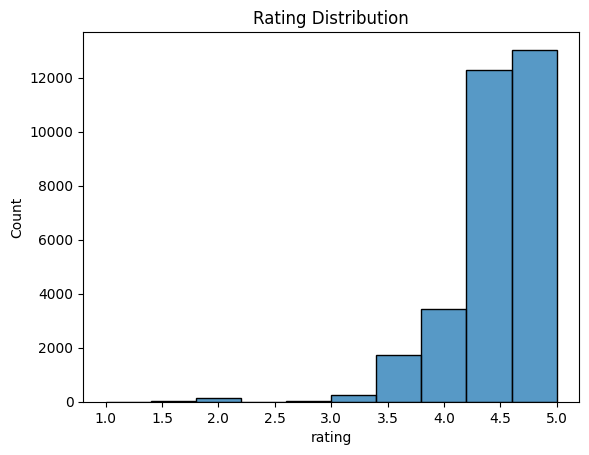

In [292]:
# Rating Distribution

sns.histplot(df['rating'],bins=10)
plt.title("Rating Distribution")
plt.show()

Most products have ratings between 4.2 and 4.6.

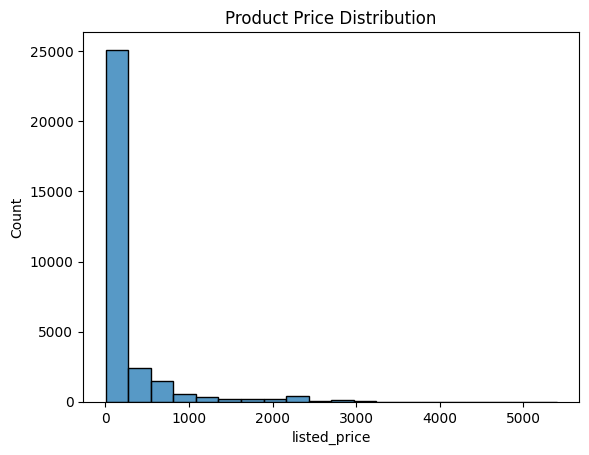

In [293]:
# Price Distribution

sns.histplot(df['listed_price'],bins=20)
plt.title("Product Price Distribution")
plt.show()

Most products are priced between 10 and 100.

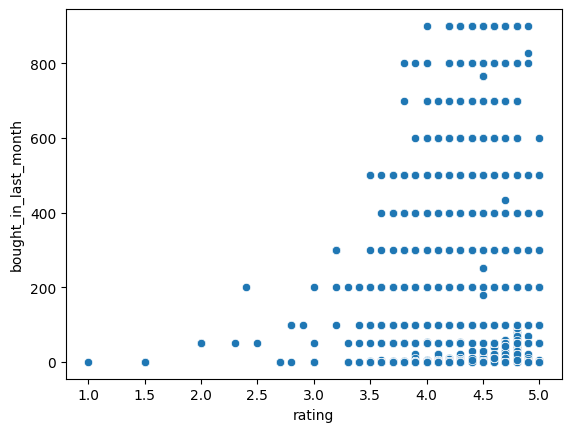

In [294]:
sns.scatterplot(
    x=df['rating'],
    y=df['bought_in_last_month'])
plt.show()

Products with ratings above 4.5 tend to have higher monthly purchases.

In [295]:
df.sort_values('discount_percentage',ascending=False)[['title','discount_percentage']].head(10)

,title,discount_percentage
7988,Samsung Electronics Galaxy Watch 4 Classic 42m...,85.415586
9633,Samsung Galaxy Watch 4 Classic 42mm Smartwatch...,82.925996
6409,Monster Clarity 101Plus AirLinks Wireless Earb...,82.562940
5389,"Monster Shock Portable Bluetooth Speaker,30W L...",82.504125
37626,"Monster Open Ear AC360, Wireless Bluetooth Rot...",82.357786
34825,"Monster Open Ear AC360, Wireless Bluetooth Rot...",82.357786
34703,"Monster Open Ear AC360, Wireless Bluetooth Rot...",82.357786
35646,"Monster Open Ear AC360, Wireless Bluetooth Rot...",82.357786
38423,"Monster Open Ear AC360, Wireless Bluetooth Rot...",82.357786
30353,"Monster Open Ear AC360, Wireless Bluetooth Rot...",82.357786


Electronics products tend to have larger discounts.

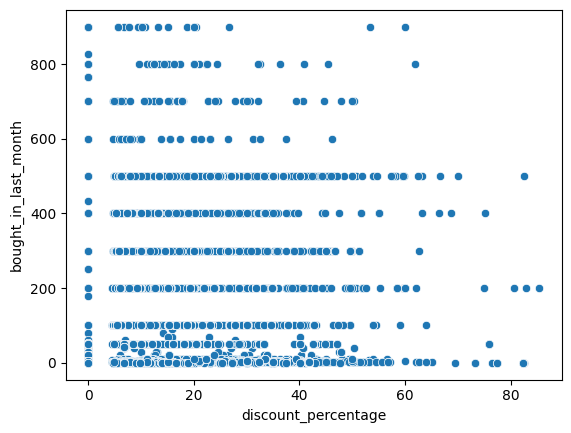

In [296]:
sns.scatterplot(
    x=df['discount_percentage'],
    y=df['bought_in_last_month'])
plt.show()

Higher discounts often correlate with higher purchase volume.

In [297]:
df.groupby('is_sponsored')['current/discounted_price'].mean()

is_sponsored
Organic      233.515464
Sponsored    141.118064
Name: current/discounted_price, dtype: float64

Organic products tend to have slightly higher average prices.

In [298]:
df.groupby('is_best_seller')['rating'].mean()

is_best_seller
Amazon's             4.550230
Best Seller          4.539556
Ends in              4.328866
Limited time deal    4.641565
No Badge             4.419123
Save 10%             4.200000
Save 12%             4.300000
Save 17%             4.400000
Save 18%             4.300000
Save 30%             4.300000
Save 77%             4.400000
Save 9%              4.871429
Name: rating, dtype: float64

Best seller products usually have ratings above 4.4.

In [299]:
df.sort_values('bought_in_last_month',ascending=False)[['title','bought_in_last_month']].head(10)

,title,bought_in_last_month
3519,EPSON 522 EcoTank Ink Ultra-high Capacity Bott...,900.0
3441,EPSON 410 Claria Premium Ink Standard Capacity...,900.0
3630,"Canon CLI-251 Genuine Three Color Multi Pack, ...",900.0
3367,Canon Office Products 2198C001 Canon MP11DX-2 ...,900.0
3684,EPSON 812 DURABrite Ultra Ink High Capacity Cy...,900.0
3354,Ubisoft RockSmith Real Tone Cable,900.0
3660,8BitDo Ultimate 2 Wireless Controller for Wind...,900.0
3373,VTech VG208 DECT 6.0 Corded/Cordless Phone for...,900.0
3312,AT&T DECT 6.0 Expandable Cordless Phone with A...,900.0
3243,Texas Instruments TI-30X IIS 2-Line Scientific...,900.0


High-demand products often combine good ratings and competitive pricing.

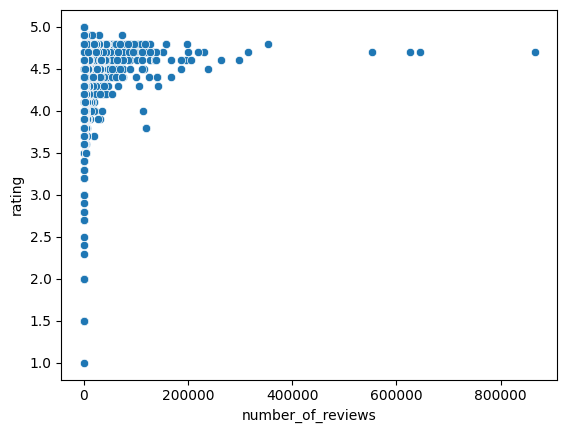

In [300]:
sns.scatterplot(
    x=df["number_of_reviews"],
    y=df["rating"]
)
plt.show()

Products with more reviews often maintain stable high ratings, indicating trust.

In [301]:
df.to_csv('amazon_cleaned.csv',index=False)

• Products with ratings above 4.5 generate higher purchase demand.
• Discounts significantly influence customer buying behavior.
• Best seller products maintain high ratings and strong review counts.

In [302]:
from sqlalchemy import create_engine

# step 1: conncet to postgresql
# replace placholder with your actual details
username="postgres"
password="rohit"
host="localhost"
port="5432"
database="sales_analysis"

engine=create_engine(f"postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}")
# step 2 : load dataframe into postgreaql
table_name= "online_sales"  #choose any table name
df.to_sql(table_name,engine,if_exists="replace",index=False)
print(f"data successfull load into table'{table_name}' in database '{database} ',")

data successfull load into table'online_sales' in database 'sales_analysis ',
